In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import scipy.cluster.hierarchy as sc
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import collections
from mlxtend.preprocessing.transactionencoder import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import fpgrowth
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import RandomForestRegressor


[[ 1.67042009 -0.14192745]
 [-0.75037648  0.04144907]
 [ 0.95041155 -0.08550549]
 ...
 [ 1.00220903  0.33367734]
 [-0.96482583  0.01726801]
 [-0.27239678  0.77764902]] [1 0 0 0 1 1 0 1 0 0 1 1 0 0 0 1 0 1 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 1 0 1
 1 1 1 1 1 0 0 1 1 0 0 0 1 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1
 0 1 1 0 1 1 1 0 0 1 1 1 0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 1 0 1 1 1 1 0 0 1 1
 0 1 0 0 0 0 1 1 0 1 1 1 1 0 1 1 0 1 1 1 1 0 1 1 0 0 1 0 0 1 0 1 1 0 1 1 1
 1 1 0 0 0 1 1 1 0 0 0 0 1 1 0 1 1 1 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1
 0 1 1 0 1 1 1 1 0 0 0 1 1 1 1 1 0 0 0 1 1 0 1 0 1 0 1 1 0 1 1 0 0 0 0 0 0
 1 0 1 0 1 1 0 0 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0 1 1 1 0 0 0 1 0 1 0 0 1 0 1
 0 1 1 1 0 1 1 1 0 1 0 0 0 0 1 1 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 1 1 0 1 0 1
 0 1 1 0 1 1 1 1 1 1 1 1 1 0 0 1 0 1 0 0 0 0 1 0 1 1 0 1 1 1 1 0 1 1 1 0 1
 0 0 1 1 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 1 1 1 0 0 0 0 0
 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 0 0 1 1 0 1 1 1 1 1 1 0 1 0 0 0 0 1 1
 1 0 1 

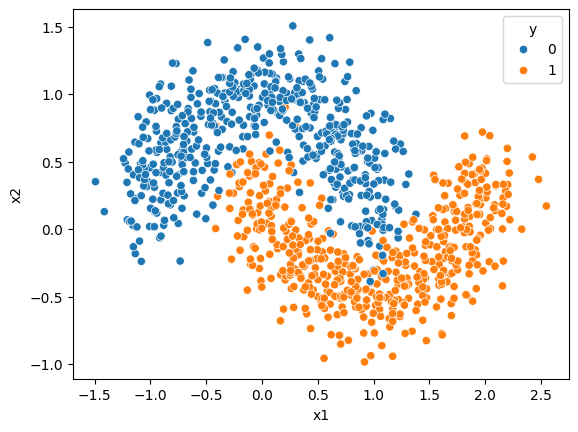

100.0 96.5
97.25 97.5
86.5 92.0
Voting Accuracy: 98.0 98.0
     dt  svm  gnb  vc
0     0    0    0   0
1     1    1    1   1
2     1    1    1   1
3     0    0    0   0
4     1    1    1   1
..   ..  ...  ...  ..
195   1    0    0   0
196   1    1    1   1
197   0    0    0   0
198   1    1    1   1
199   1    1    0   1

[200 rows x 4 columns]


In [50]:
x,y = make_moons(n_samples=1000,noise=0.2)
print(x,y)
df = {"x1":x[:,0],"x2":x[:,1],"y":y}
dataset = pd.DataFrame(df)
print(dataset.head())
sns.scatterplot(x="x1",y="x2",data=dataset,hue="y")
plt.show()
x_a = dataset.iloc[:,:-1]
y_a = dataset["y"]
x_train, x_test, y_train, y_test = train_test_split(x_a,y_a,test_size=0.2,random_state=13)
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)
print(dt.score(x_train,y_train)*100,dt.score(x_test,y_test)*100)
sv = SVC()
sv.fit(x_train,y_train)
print(sv.score(x_train,y_train)*100,sv.score(x_test,y_test)*100)
gnb = GaussianNB()
gnb.fit(x_train,y_train)
print(gnb.score(x_train,y_train)*100,gnb.score(x_test,y_test)*100)
li = [
    ("dt1", DecisionTreeClassifier()),
    ("sv1", SVC(probability=True)),
    ("gnb1", GaussianNB())
]
vc = VotingClassifier(li,weights=[5,4,7])
vc.fit(x_train,y_train)
print("Voting Accuracy:",
      vc.score(x_train, y_train)*100,
      vc.score(x_test, y_test)*100)
prd = {"dt":dt.predict(x_test),"svm":sv.predict(x_test),"gnb":gnb.predict(x_test),"vc":vc.predict(x_test)}
print(pd.DataFrame(prd))

In [51]:
dataset = pd.read_csv("../datasets/cgpa_package.csv")
dataset.head()
dataset.isnull().sum()
x = dataset.iloc[:,:-1]
y = dataset["package"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
lr = LinearRegression()
lr.fit(x_train,y_train)
print("LR:", lr.score(x_train,y_train)*100, lr.score(x_test,y_test)*100)
sv = SVR()
sv.fit(x_train,y_train)
print("SVR:", sv.score(x_train,y_train)*100, sv.score(x_test,y_test)*100)
dt = DecisionTreeRegressor()
dt.fit(x_train,y_train)
print("DT:", dt.score(x_train,y_train)*100, dt.score(x_test,y_test)*100)
li = [
    ("lr1", LinearRegression()),
    ("sv1", SVR()),
    ("dt1", DecisionTreeRegressor())
]
vc = VotingRegressor(li,weights=[2, 4, 1])
vc.fit(x_train,y_train)
print("Voting Accuracy:",
      vc.score(x_train, y_train)*100,
      vc.score(x_test, y_test)*100)
df = {"lr":lr.predict(x_test),"dt":dt.predict(x_test),"svm":sv.predict(x_test),"vc":vc.predict(x_test)}
print(pd.DataFrame(df).head(5))

LR: 85.52251040585725 85.79606813451383
SVR: 87.20087854013273 88.2775917350433
DT: 95.27687993784821 83.11400374836576
Voting Accuracy: 89.28735840641349 88.05056695089554
         lr        dt       svm        vc
0  1.979230  1.980000  2.055578  2.022967
1  3.563685  3.490000  3.613838  3.581817
2  2.837477  2.873333  2.731989  2.782320
3  3.250095  3.240000  3.277404  3.264258
4  2.977767  2.730000  2.905945  2.901330


[[ 0.90901839 -0.68528629]
 [ 1.4266518  -0.34481419]
 [ 1.30272921 -0.64636782]
 ...
 [ 0.04242354  0.93313447]
 [ 0.45152339 -0.34713169]
 [ 0.68015032  0.46650058]] [1 1 1 1 1 0 1 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 1 0 1 1 0 1 1 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 1 0 0 0 0 1 0
 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 1 1 0 1 0 0 1 1 0 0 0 1 1 0 0 1 1 1 1 0 0 0
 1 0 0 0 0 0 1 0 1 0 0 0 1 1 1 1 0 1 1 1 1 0 1 0 1 0 1 1 0 0 0 1 1 0 0 0 1
 1 0 0 0 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 0 1 1 0 1 0 0 1 0 0 1 0 1 1 1 0 1 1
 1 0 0 1 0 0 1 0 0 1 1 1 1 0 0 0 1 1 1 0 0 0 1 1 0 1 0 0 1 0 0 1 1 0 1 1 1
 1 0 0 1 1 0 1 0 0 1 0 0 1 0 0 0 0 1 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 0 0 1 0 0 1 1 1 0 1 0 1 0 1 1 1 0 0 0 1 1 1 1 1 0 1 0 0 1 1 0 0 0
 0 0 1 1 0 1 0 1 1 0 1 1 0 0 1 0 1 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 1
 0 1 0 0 0 0 1 1 0 0 0 0 1 0 1 0 1 0 0 1 0 1 1 0 1 1 1 0 1 0 0 0 0 1 0 0 1
 0 0 1 1 1 1 0 1 0 1 0 1 1 1 1 1 0 1 1 0 0 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0
 0 0 0 

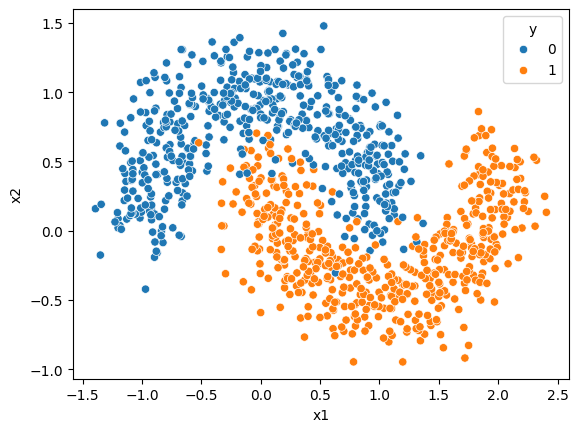

BG: 97.0 97.0
RF: 100.0 95.5


In [52]:
x,y = make_moons(n_samples=1000,noise=0.2)
print(x,y)
df = {"x1":x[:,0],"x2":x[:,1],"y":y}
dataset = pd.DataFrame(df)
print(dataset.head())
sns.scatterplot(x="x1",y="x2",data=dataset,hue="y")
plt.show()
x_a = dataset.iloc[:,:-1]
y_a = dataset["y"]
x_train, x_test, y_train, y_test = train_test_split(x_a,y_a,test_size=0.2,random_state=42)
bg = BaggingClassifier(estimator=SVC(),n_estimators=30)
bg.fit(x_train,y_train)
print("BG:", bg.score(x_train,y_train)*100, bg.score(x_test,y_test)*100)
rf = RandomForestClassifier(n_estimators=30)
rf.fit(x_train,y_train)
print("RF:", rf.score(x_train,y_train)*100, rf.score(x_test,y_test)*100)

In [59]:
dataset = pd.read_csv("../datasets/cgpa_package.csv")
dataset.head()
dataset.isnull().sum()
x = dataset.iloc[:,:-1]
y = dataset["package"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
bg = BaggingRegressor(estimator=LinearRegression(),n_estimators=50, random_state=42)
bg.fit(x_train,y_train)
print("BG:", bg.score(x_train,y_train)*100, bg.score(x_test,y_test)*100)
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)
rf.fit(x_train,y_train)
print("RF:", rf.score(x_train,y_train)*100, rf.score(x_test,y_test)*100)

BG: 85.52154958770149 85.80514290466604
RF: 91.09181945513902 86.66621939190397
